# De Jure EDA

In [25]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 120)
pd.set_option("display.max_rows", 120)

In [26]:
DATA_PATH = Path("../data/raw/country_year_final_panel_full_new.csv")

if not DATA_PATH.exists():
    DATA_PATH = Path("/Users/RaulPerez/Documents/Projects/cumulative_report/data/raw/country_year_final_panel_full_new.csv")

df = pd.read_csv(DATA_PATH)

rule_prefixes = (
    "C_", "I_", "P_",
    "IM_", "GOV_", "PRESS_",
    "APPEAL_", "EXEMPTION_", "LAWSUIT", "REG_",
)

rule_cols = [c for c in df.columns if str(c).startswith(rule_prefixes)]
id_cols = [c for c in ["COUNTRY", "iso3", "year"] if c in df.columns]

print(f"Loaded: {DATA_PATH}")
print(f"Panel shape: {df.shape[0]:,} rows x {df.shape[1]:,} columns")
print(f"ID columns: {id_cols}")
print(f"Rule columns: {len(rule_cols):,}")
print(f"Years: {df['year'].min()}-{df['year'].max()}")

df.head()

Loaded: ../data/raw/country_year_final_panel_full_new.csv
Panel shape: 8,580 rows x 742 columns
ID columns: ['COUNTRY', 'iso3', 'year']
Rule columns: 730
Years: 1894-2025


,Unnamed: 0,COUNTRY,iso3,year,dj_expression,wdj_expression,wdj_citizen,wdj_intermediaries,wdj_press,wdj_govprot,wdj_restriction,wdj_obligation,C_DISINFO_GEN,I_DISINFO_GEN,P_DISINFO_GEN,C_DISINFO_GEN_DIGI,I_DISINFO_GEN_DIGI,P_DISINFO_GEN_DIGI,C_DISINFO_GEN_CRISIS,I_DISINFO_GEN_CRISIS,P_DISINFO_GEN_CRISIS,C_MALINFO_GEN,I_MALINFO_GEN,P_MALINFO_GEN,C_MALINFO_GEN_DIGI,I_MALINFO_GEN_DIGI,P_MALINFO_GEN_DIGI,C_MALINFO_GEN_CRISIS,I_MALINFO_GEN_CRISIS,P_MALINFO_GEN_CRISIS,C_MISINFO_GEN,I_MISINFO_GEN,P_MISINFO_GEN,C_MISINFO_GEN_DIGI,I_MISINFO_GEN_DIGI,P_MISINFO_GEN_DIGI,C_MISINFO_GEN_CRISIS,I_MISINFO_GEN_CRISIS,P_MISINFO_GEN_CRISIS,C_DISINFO_HATE,I_DISINFO_HATE,P_DISINFO_HATE,C_DISINFO_HATE_DIGI,I_DISINFO_HATE_DIGI,P_DISINFO_HATE_DIGI,C_DISINFO_HATE_CRISIS,I_DISINFO_HATE_CRISIS,P_DISINFO_HATE_CRISIS,C_DISINFO_HEALTHOFF,I_DISINFO_HEALTHOFF,P_DISINFO_HEALTHOFF,C_DISINFO_HEALTHOFF_DIGI,I_DISINFO_HEALTHOFF_DIGI,P_DISINFO_HEALTHOFF_DIGI,C_DISINFO_HEALTHOFF_CRISIS,I_DISINFO_HEALTHOFF_CRISIS,P_DISINFO_HEALTHOFF_CRISIS,C_DISINFO_LIFE,I_DISINFO_LIFE,P_DISINFO_LIFE,...,C_MISINFO_UNITY_DIGI,I_MISINFO_UNITY_DIGI,P_MISINFO_UNITY_DIGI,C_MISINFO_UNITY_CRISIS,I_MISINFO_UNITY_CRISIS,P_MISINFO_UNITY_CRISIS,GOV_CENSOR,GOV_CENSOR_CRISIS,GOV_NOWARRANT,GOV_NOWARRANT_CRISIS,GOV_OVERSIGHT,GOV_OVERSIGHT_CRISIS,GOV_REGULATOR,GOV_REGULATOR_CRISIS,GOV_WARRANT,GOV_WARRANT_CRISIS,REG_RULES,REG_RULES_CRISIS,IM_DAILY,IM_DAILY_CRISIS,IM_PUBINTEREST,IM_PUBINTEREST_CRISIS,IM_EMERGENCY,IM_EMERGENCY_CRISIS,IM_PREVENTION,IM_PREVENTION_CRISIS,IM_CORRECT,IM_CORRECT_CRISIS,IM_DATA,IM_DATA_CRISIS,IM_DEPLATFORM,IM_DEPLATFORM_CRISIS,IM_FUNDING,IM_FUNDING_CRISIS,IM_LICENSE,IM_LICENSE_CRISIS,IM_OVERSIGHT,IM_OVERSIGHT_CRISIS,IM_REPORT,IM_REPORT_CRISIS,PRESS_CORRECT,PRESS_CORRECT_CRISIS,PRESS_FUNDING,PRESS_FUNDING_CRISIS,PRESS_LICENSE,PRESS_LICENSE_CRISIS,PRESS_OVERSIGHT,PRESS_OVERSIGHT_CRISIS,PRESS_REPORT,PRESS_REPORT_CRISIS,APPEAL_NONREG,APPEAL_NONREG_CRISIS,APPEAL_REG,APPEAL_REG_CRISIS,EXEMPTION_LEG,EXEMPTION_LEG_CRISIS,EXEMPTION_SEPLEG,EXEMPTION_SEPLEG_CRISIS,LAWSUIT,LAWSUIT_CRISIS
0,1,ASEAN,ASEAN,1894,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,2,ASEAN,ASEAN,1895,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,3,ASEAN,ASEAN,1896,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3,4,ASEAN,ASEAN,1897,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
4,5,ASEAN,ASEAN,1898,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


In [27]:
allowed_rule_values = {-1, 0, 1}

rule_values = pd.Series(
    df[rule_cols].to_numpy().ravel(),
    name="value",
).dropna()

rule_value_counts = (
    rule_values
    .value_counts()
    .sort_index()
    .rename_axis("value")
    .reset_index(name="cell_count")
)

observed_rule_values = set(rule_value_counts["value"].tolist())
unexpected_rule_values = sorted(observed_rule_values - allowed_rule_values)

columns_with_unexpected_values = []
for col in rule_cols:
    col_values = set(df[col].dropna().unique().tolist())
    unexpected = sorted(col_values - allowed_rule_values)
    if unexpected:
        columns_with_unexpected_values.append({
            "column": col,
            "unexpected_values": unexpected,
        })

validation_summary = pd.DataFrame({
    "check": [
        "rule columns identified",
        "observed rule values",
        "unexpected values outside {-1, 0, 1}",
        "columns with unexpected values",
    ],
    "result": [
        len(rule_cols),
        sorted(observed_rule_values),
        unexpected_rule_values,
        len(columns_with_unexpected_values),
    ],
})

display(validation_summary)
display(rule_value_counts)

assert not unexpected_rule_values, f"Unexpected rule values found: {unexpected_rule_values}"
assert not columns_with_unexpected_values, columns_with_unexpected_values[:10]

,check,result
0,rule columns identified,730
1,observed rule values,"[-1, 0, 1]"
2,"unexpected values outside {-1, 0, 1}",[]
3,columns with unexpected values,0


,value,cell_count
0,-1,3983
1,0,6246609
2,1,12808


## Topical Trends

Track active rule coverage by actor family over time.

In [28]:
citizen_cols = [c for c in rule_cols if c.startswith("C_")]
press_cols = [c for c in rule_cols if c.startswith("P_")]
press_obligation_cols = [c for c in rule_cols if c.startswith("PRESS_")]
internet_cols = [c for c in rule_cols if c.startswith("I_")]
intermediary_cols = [c for c in rule_cols if c.startswith("IM_")]

trend_groups = {
    "Citizens (C_)": citizen_cols,
    "Press (P_ + PRESS_)": press_cols + press_obligation_cols,
    "Internet (I_ + IM_)": internet_cols + intermediary_cols,
}

topical_group_summary = pd.DataFrame({
    "group": trend_groups.keys(),
    "rule_columns": [len(cols) for cols in trend_groups.values()],
})

topical_group_summary

,group,rule_columns
0,Citizens (C_),226
1,Press (P_ + PRESS_),235
2,Internet (I_ + IM_),247


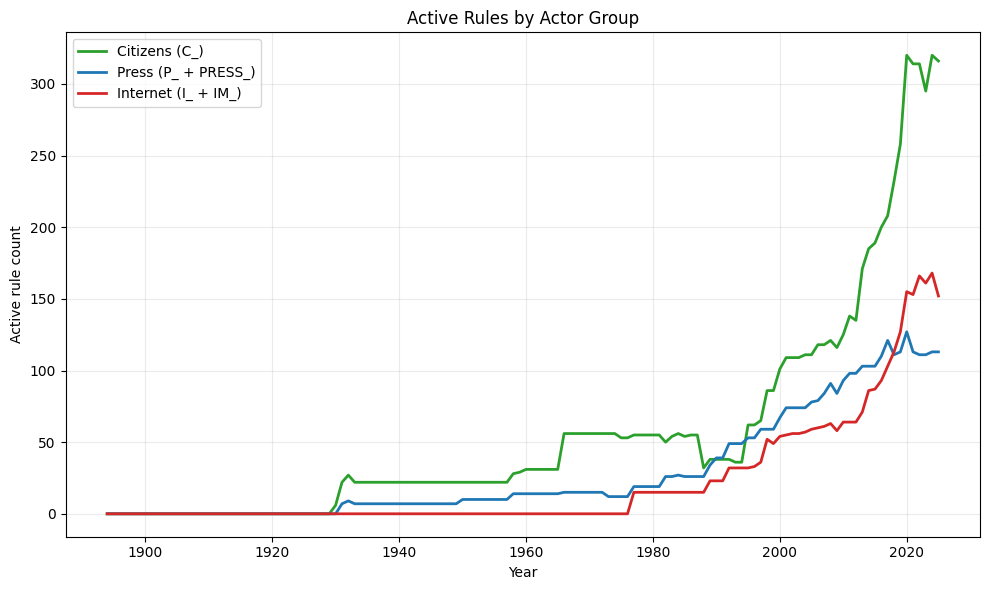

,year,Citizens (C_),Press (P_ + PRESS_),Internet (I_ + IM_)
122,2016,200,110,93
123,2017,208,121,103
124,2018,232,111,113
125,2019,258,113,127
126,2020,320,127,155
127,2021,314,113,153
128,2022,314,111,166
129,2023,295,111,161
130,2024,320,113,168
131,2025,316,113,152


In [29]:
yearly_active_rules = pd.DataFrame({"year": df["year"]})

for group_name, cols in trend_groups.items():
    yearly_active_rules[group_name] = df[cols].fillna(0).ne(0).sum(axis=1)

yearly_active_rules = (
    yearly_active_rules
    .groupby("year", as_index=False)
    .sum()
)

plt.figure(figsize=(10, 6))
plt.plot(
    yearly_active_rules["year"],
    yearly_active_rules["Citizens (C_)"],
    label="Citizens (C_)",
    color="#2ca02c",
    linewidth=2,
)
plt.plot(
    yearly_active_rules["year"],
    yearly_active_rules["Press (P_ + PRESS_)"],
    label="Press (P_ + PRESS_)",
    color="#1f77b4",
    linewidth=2,
)
plt.plot(
    yearly_active_rules["year"],
    yearly_active_rules["Internet (I_ + IM_)"],
    label="Internet (I_ + IM_)",
    color="#d62728",
    linewidth=2,
)

plt.xlabel("Year")
plt.ylabel("Active rule count")
plt.title("Active Rules by Actor Group")
plt.grid(True, alpha=0.25)
plt.legend()
plt.tight_layout()
plt.show()

yearly_active_rules.tail(10)

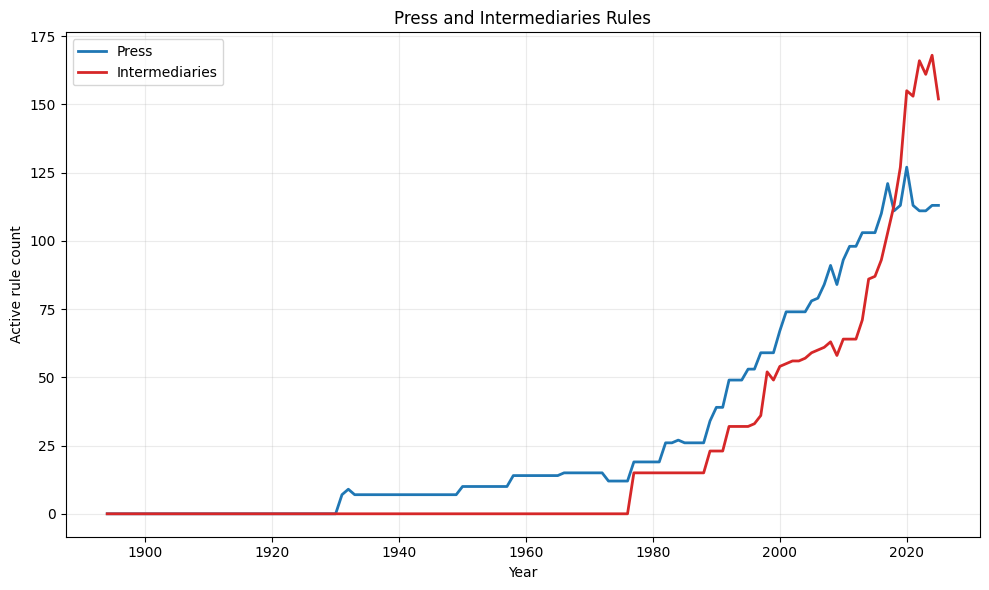

,year,Press (P_ + PRESS_),Internet (I_ + IM_)
122,2016,110,93
123,2017,121,103
124,2018,111,113
125,2019,113,127
126,2020,127,155
127,2021,113,153
128,2022,111,166
129,2023,111,161
130,2024,113,168
131,2025,113,152


In [30]:
plt.figure(figsize=(10, 6))
plt.plot(
    yearly_active_rules["year"],
    yearly_active_rules["Press (P_ + PRESS_)"],
    label="Press",
    color="#1f77b4",
    linewidth=2,
)
plt.plot(
    yearly_active_rules["year"],
    yearly_active_rules["Internet (I_ + IM_)"],
    label="Intermediaries",
    color="#d62728",
    linewidth=2,
)

plt.xlabel("Year")
plt.ylabel("Active rule count")
plt.title("Press and Intermediaries Rules")
plt.grid(True, alpha=0.25)
plt.legend()
plt.tight_layout()
plt.show()

yearly_active_rules[["year", "Press (P_ + PRESS_)", "Internet (I_ + IM_)"]].tail(10)

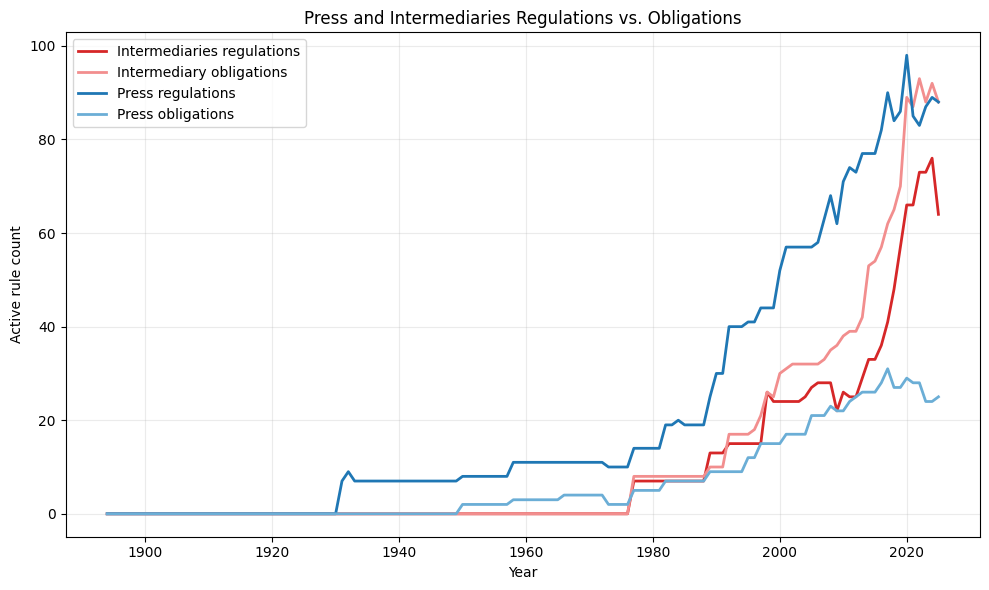

,year,I_,IM_,P_,PRESS_
122,2016,36,57,82,28
123,2017,41,62,90,31
124,2018,48,65,84,27
125,2019,57,70,86,27
126,2020,66,89,98,29
127,2021,66,87,85,28
128,2022,73,93,83,28
129,2023,73,88,87,24
130,2024,76,92,89,24
131,2025,64,88,88,25


In [31]:
yearly_family_active_rules = pd.DataFrame({
    "year": df["year"],
    "I_": df[internet_cols].fillna(0).ne(0).sum(axis=1),
    "IM_": df[intermediary_cols].fillna(0).ne(0).sum(axis=1),
    "P_": df[press_cols].fillna(0).ne(0).sum(axis=1),
    "PRESS_": df[press_obligation_cols].fillna(0).ne(0).sum(axis=1),
})

yearly_family_active_rules = (
    yearly_family_active_rules
    .groupby("year", as_index=False)
    .sum()
)

plt.figure(figsize=(10, 6))
plt.plot(
    yearly_family_active_rules["year"],
    yearly_family_active_rules["I_"],
    label="Intermediaries regulations",
    color="#d62728",
    linewidth=2,
)
plt.plot(
    yearly_family_active_rules["year"],
    yearly_family_active_rules["IM_"],
    label="Intermediary obligations",
    color="#f28e8e",
    linewidth=2,
)
plt.plot(
    yearly_family_active_rules["year"],
    yearly_family_active_rules["P_"],
    label="Press regulations",
    color="#1f77b4",
    linewidth=2,
)
plt.plot(
    yearly_family_active_rules["year"],
    yearly_family_active_rules["PRESS_"],
    label="Press obligations",
    color="#6baed6",
    linewidth=2,
)

plt.xlabel("Year")
plt.ylabel("Active rule count")
plt.title("Press and Intermediaries Regulations vs. Obligations")
plt.grid(True, alpha=0.25)
plt.legend()
plt.tight_layout()
plt.show()

yearly_family_active_rules.tail(10)

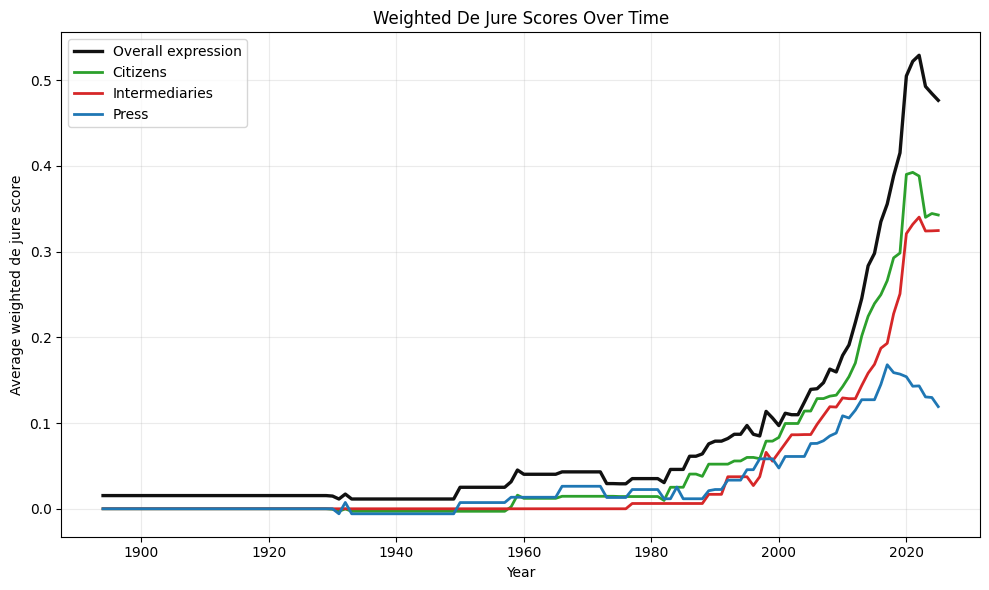

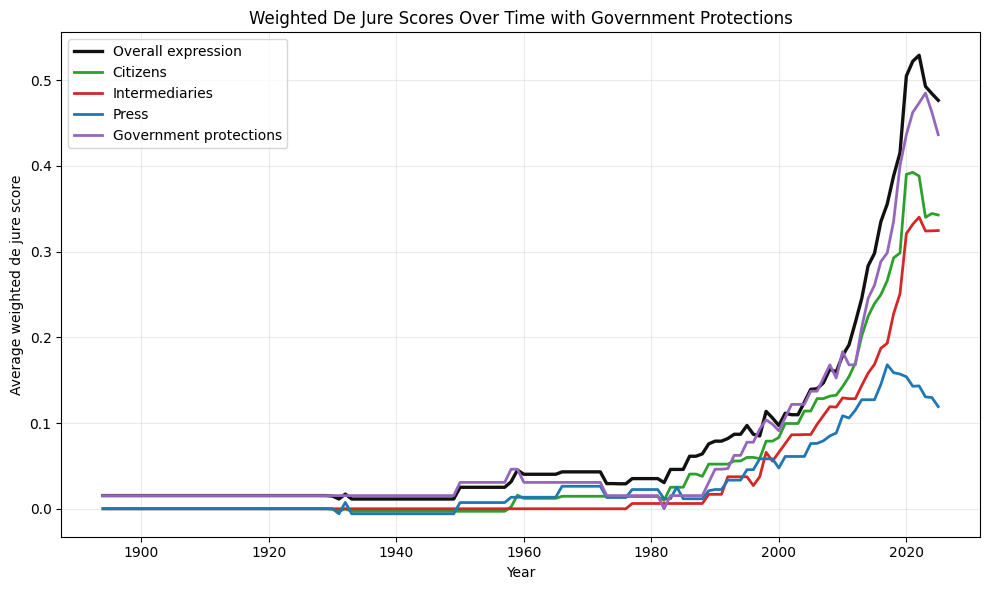

,year,wdj_expression,wdj_citizen,wdj_intermediaries,wdj_press,wdj_govprot
122,2016,0.334950,0.249742,0.187300,0.145031,0.288462
123,2017,0.355596,0.266153,0.193085,0.168036,0.298547
124,2018,0.388365,0.292753,0.227480,0.158848,0.335470
125,2019,0.415253,0.298388,0.250790,0.157139,0.400085
126,2020,0.504928,0.390131,0.320971,0.154046,0.436545
127,2021,0.522036,0.392489,0.331868,0.142984,0.462470
128,2022,0.529132,0.388191,0.340284,0.143340,0.473460
129,2023,0.492783,0.340044,0.324092,0.130513,0.485035
130,2024,0.484416,0.344505,0.324272,0.129829,0.462812
131,2025,0.476545,0.342766,0.324609,0.119188,0.436459


In [36]:
de_jure_score_cols = [
    "wdj_expression",
    "wdj_citizen",
    "wdj_intermediaries",
    "wdj_press",
    "wdj_govprot",
]

yearly_de_jure_scores = (
    df.groupby("year", as_index=False)[de_jure_score_cols]
    .mean()
)

plt.figure(figsize=(10, 6))
plt.plot(
    yearly_de_jure_scores["year"],
    yearly_de_jure_scores["wdj_expression"],
    label="Overall expression",
    color="#111111",
    linewidth=2.4,
)
plt.plot(
    yearly_de_jure_scores["year"],
    yearly_de_jure_scores["wdj_citizen"],
    label="Citizens",
    color="#2ca02c",
    linewidth=2,
)
plt.plot(
    yearly_de_jure_scores["year"],
    yearly_de_jure_scores["wdj_intermediaries"],
    label="Intermediaries",
    color="#d62728",
    linewidth=2,
)
plt.plot(
    yearly_de_jure_scores["year"],
    yearly_de_jure_scores["wdj_press"],
    label="Press",
    color="#1f77b4",
    linewidth=2,
)

plt.xlabel("Year")
plt.ylabel("Average weighted de jure score")
plt.title("Weighted De Jure Scores Over Time")
plt.grid(True, alpha=0.25)
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))
plt.plot(
    yearly_de_jure_scores["year"],
    yearly_de_jure_scores["wdj_expression"],
    label="Overall expression",
    color="#111111",
    linewidth=2.4,
)
plt.plot(
    yearly_de_jure_scores["year"],
    yearly_de_jure_scores["wdj_citizen"],
    label="Citizens",
    color="#2ca02c",
    linewidth=2,
)
plt.plot(
    yearly_de_jure_scores["year"],
    yearly_de_jure_scores["wdj_intermediaries"],
    label="Intermediaries",
    color="#d62728",
    linewidth=2,
)
plt.plot(
    yearly_de_jure_scores["year"],
    yearly_de_jure_scores["wdj_press"],
    label="Press",
    color="#1f77b4",
    linewidth=2,
)
plt.plot(
    yearly_de_jure_scores["year"],
    yearly_de_jure_scores["wdj_govprot"],
    label="Government protections",
    color="#9467bd",
    linewidth=2,
)

plt.xlabel("Year")
plt.ylabel("Average weighted de jure score")
plt.title("Weighted De Jure Scores Over Time with Government Protections")
plt.grid(True, alpha=0.25)
plt.legend()
plt.tight_layout()
plt.show()

yearly_de_jure_scores.tail(10)

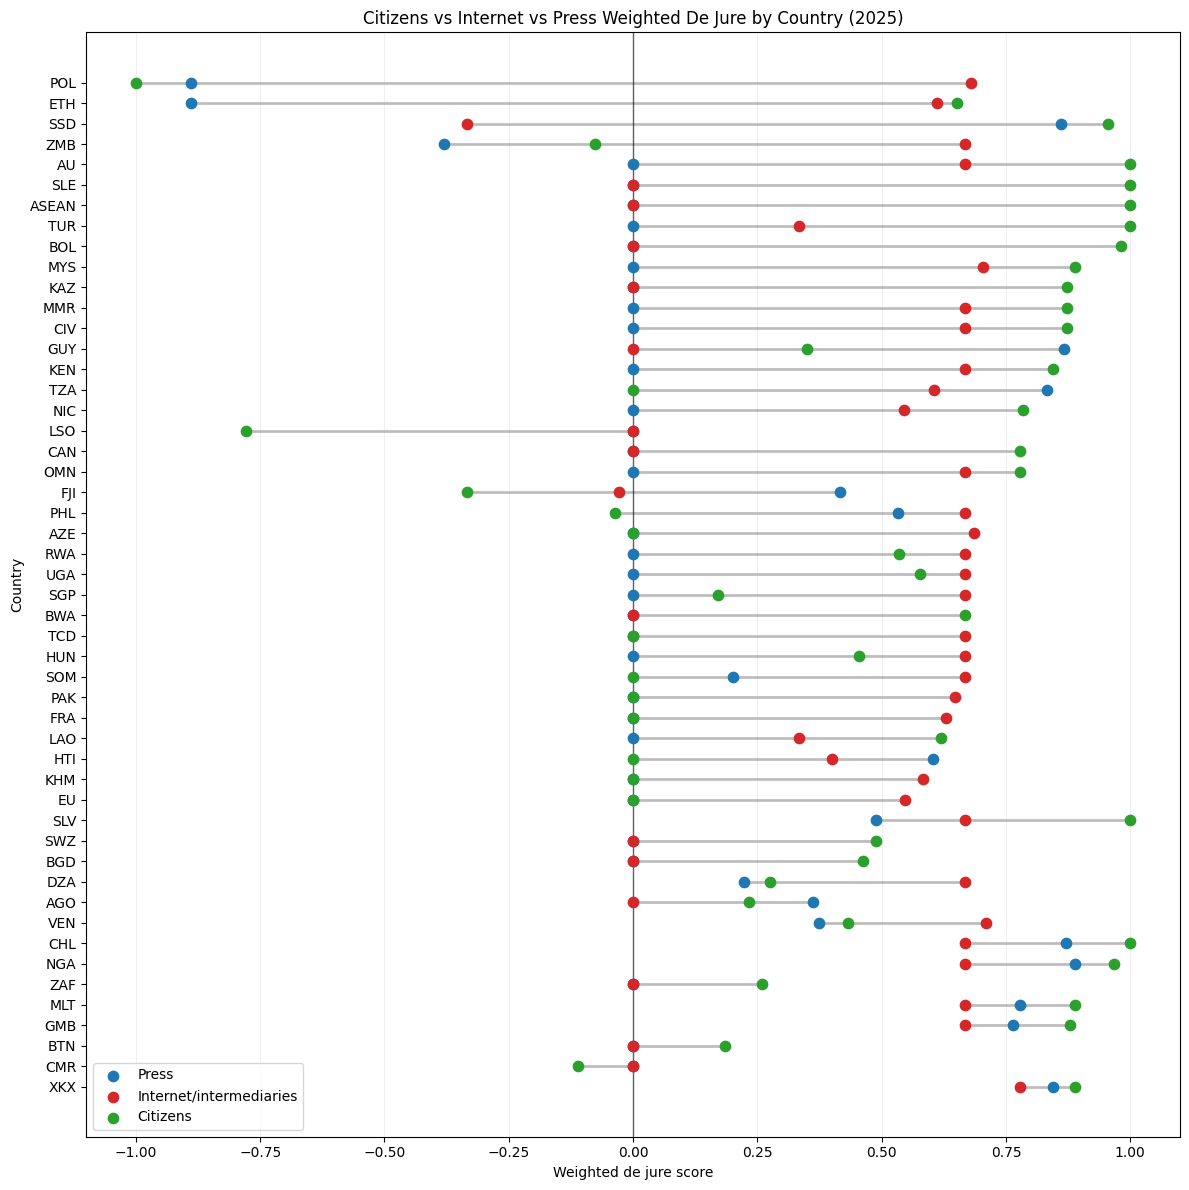

,COUNTRY,iso3,wdj_press,wdj_intermediaries,wdj_citizen,spread,active_rule_count_total
0,Kosovo,XKX,0.844444,0.777778,0.888889,0.111111,11
1,Cameroon,CMR,0.000000,0.000000,-0.111111,0.111111,9
2,Bhutan,BTN,0.000000,0.000000,0.185185,0.185185,9
3,The Gambia,GMB,0.763889,0.666667,0.878788,0.212121,21
4,Malta,MLT,0.777778,0.666667,0.888889,0.222222,9
5,South Africa,ZAF,0.000000,0.000000,0.259259,0.259259,4
6,Nigeria,NGA,0.888889,0.666667,0.968254,0.301587,18
7,Chile,CHL,0.870370,0.666667,1.000000,0.333333,14
8,Venezuela,VEN,0.374074,0.709402,0.432749,0.335328,56
9,Angola,AGO,0.361111,0.000000,0.232323,0.361111,19


In [33]:
plot_year = 2025

cip_df = (
    df.loc[df["year"] == plot_year, [
        "COUNTRY",
        "iso3",
        "wdj_citizen",
        "wdj_intermediaries",
        "wdj_press",
    ]]
    .dropna()
    .copy()
)

active_rule_count_total = (
    df.loc[df["year"] == plot_year, rule_cols]
    .fillna(0)
    .ne(0)
    .sum(axis=1)
    .to_numpy()
)

cip_df["active_rule_count_total"] = active_rule_count_total

score_cols = ["wdj_citizen", "wdj_intermediaries", "wdj_press"]
cip_df = cip_df[(cip_df[score_cols] != 0).any(axis=1)].copy()
cip_df["spread"] = cip_df[score_cols].max(axis=1) - cip_df[score_cols].min(axis=1)

cip_df = cip_df.sort_values("spread").reset_index(drop=True)
y_pos = range(len(cip_df))

plt.figure(figsize=(12, 12))

for i, row in cip_df.iterrows():
    x_values = sorted([
        row["wdj_press"],
        row["wdj_intermediaries"],
        row["wdj_citizen"],
    ])
    plt.plot(
        [x_values[0], x_values[-1]],
        [i, i],
        color="#bdbdbd",
        linewidth=2,
        zorder=1,
    )

plt.scatter(
    cip_df["wdj_press"],
    y_pos,
    color="#1f77b4",
    s=55,
    label="Press",
    zorder=3,
)
plt.scatter(
    cip_df["wdj_intermediaries"],
    y_pos,
    color="#d62728",
    s=55,
    label="Internet/intermediaries",
    zorder=3,
)
plt.scatter(
    cip_df["wdj_citizen"],
    y_pos,
    color="#2ca02c",
    s=55,
    label="Citizens",
    zorder=3,
)

plt.axvline(0, color="black", linewidth=1, alpha=0.6)
plt.yticks(y_pos, cip_df["iso3"])
plt.xlabel("Weighted de jure score")
plt.ylabel("Country")
plt.title(f"Citizens vs Internet vs Press Weighted De Jure by Country ({plot_year})")
plt.grid(True, axis="x", alpha=0.2)
plt.legend()
plt.tight_layout()
plt.show()

cip_df[[
    "COUNTRY",
    "iso3",
    "wdj_press",
    "wdj_intermediaries",
    "wdj_citizen",
    "spread",
    "active_rule_count_total",
]]

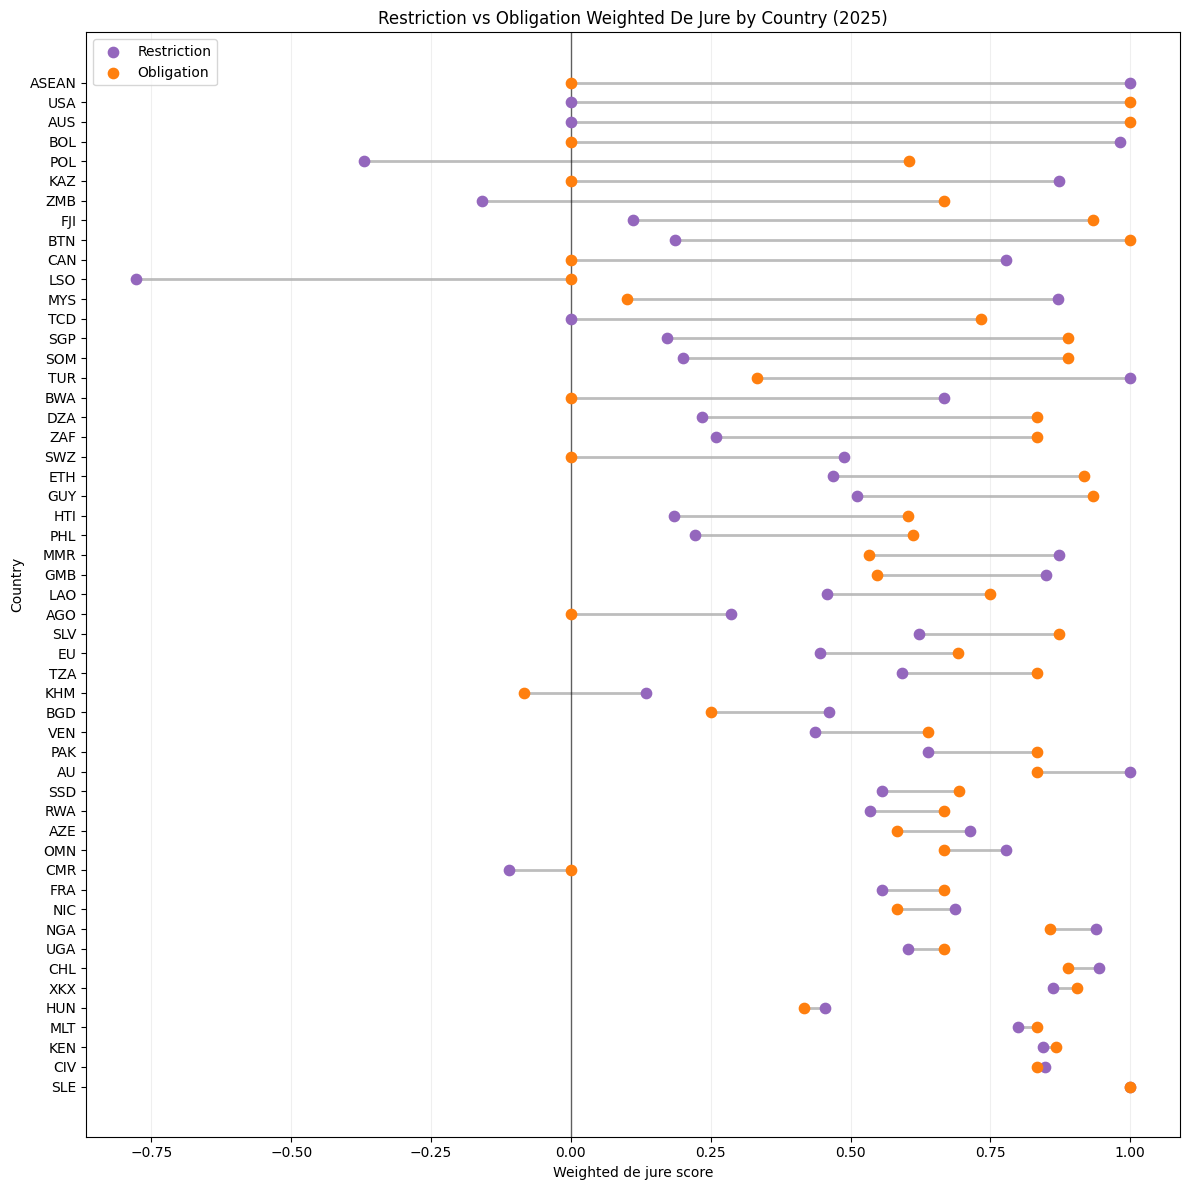

,COUNTRY,iso3,wdj_restriction,wdj_obligation,spread,active_rule_count_total
0,Sierra Leone,SLE,1.000000,1.000000,0.000000,7
1,"Côte d""Ivoire",CIV,0.847222,0.833333,0.013889,10
2,Kenya,KEN,0.844444,0.866667,0.022222,15
3,Malta,MLT,0.800000,0.833333,0.033333,9
4,Hungary,HUN,0.454248,0.416667,0.037582,21
5,Kosovo,XKX,0.861111,0.904762,0.043651,11
6,Chile,CHL,0.944444,0.888889,0.055556,14
7,Uganda,UGA,0.603175,0.666667,0.063492,8
8,Nigeria,NGA,0.939394,0.857143,0.082251,18
9,Nicaragua,NIC,0.686869,0.583333,0.103535,30


In [34]:
plot_year = 2025

restriction_obligation_df = (
    df.loc[df["year"] == plot_year, [
        "COUNTRY",
        "iso3",
        "wdj_restriction",
        "wdj_obligation",
    ]]
    .dropna()
    .copy()
)

restriction_obligation_df["active_rule_count_total"] = (
    df.loc[df["year"] == plot_year, rule_cols]
    .fillna(0)
    .ne(0)
    .sum(axis=1)
    .to_numpy()
)

score_cols = ["wdj_restriction", "wdj_obligation"]
restriction_obligation_df = restriction_obligation_df[
    (restriction_obligation_df[score_cols] != 0).any(axis=1)
].copy()
restriction_obligation_df["spread"] = (
    restriction_obligation_df[score_cols].max(axis=1)
    - restriction_obligation_df[score_cols].min(axis=1)
)

restriction_obligation_df = restriction_obligation_df.sort_values("spread").reset_index(drop=True)
y_pos = range(len(restriction_obligation_df))

plt.figure(figsize=(12, 12))

for i, row in restriction_obligation_df.iterrows():
    x_values = sorted([row["wdj_restriction"], row["wdj_obligation"]])
    plt.plot(
        [x_values[0], x_values[-1]],
        [i, i],
        color="#bdbdbd",
        linewidth=2,
        zorder=1,
    )

plt.scatter(
    restriction_obligation_df["wdj_restriction"],
    y_pos,
    color="#9467bd",
    s=55,
    label="Restriction",
    zorder=3,
)
plt.scatter(
    restriction_obligation_df["wdj_obligation"],
    y_pos,
    color="#ff7f0e",
    s=55,
    label="Obligation",
    zorder=3,
)

plt.axvline(0, color="black", linewidth=1, alpha=0.6)
plt.yticks(y_pos, restriction_obligation_df["iso3"])
plt.xlabel("Weighted de jure score")
plt.ylabel("Country")
plt.title(f"Restriction vs Obligation Weighted De Jure by Country ({plot_year})")
plt.grid(True, axis="x", alpha=0.2)
plt.legend()
plt.tight_layout()
plt.show()

restriction_obligation_df[[
    "COUNTRY",
    "iso3",
    "wdj_restriction",
    "wdj_obligation",
    "spread",
    "active_rule_count_total",
]]

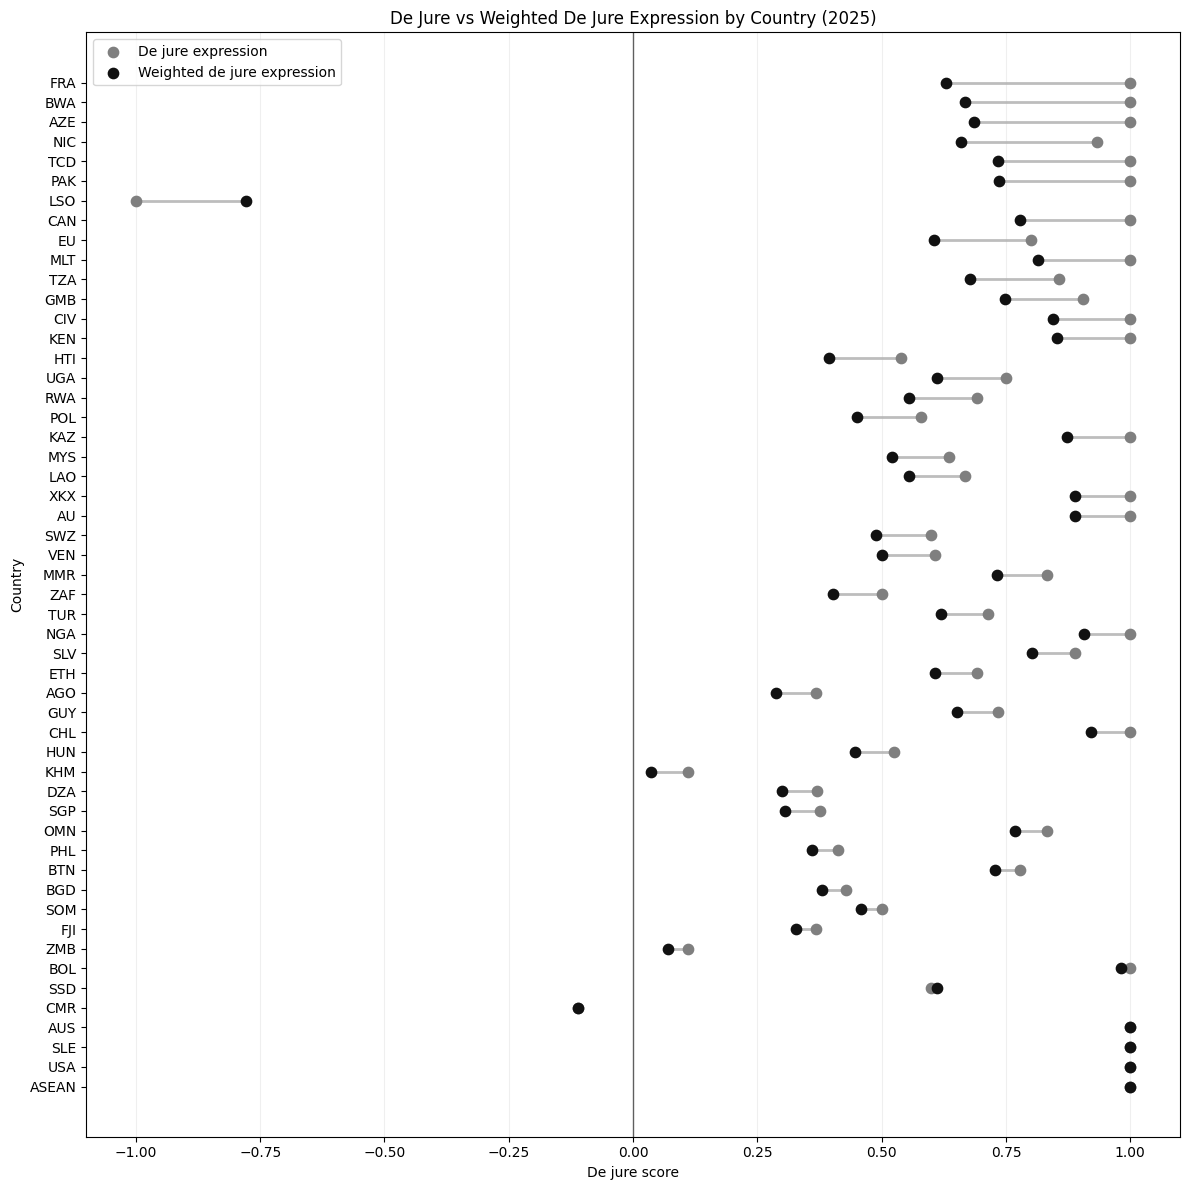

,COUNTRY,iso3,dj_expression,wdj_expression,spread,active_rule_count_total
0,ASEAN,ASEAN,1.000000,1.000000,0.000000,3
1,United States,USA,1.000000,1.000000,0.000000,2
2,Sierra Leone,SLE,1.000000,1.000000,0.000000,7
3,Australia,AUS,1.000000,1.000000,0.000000,1
4,Cameroon,CMR,-0.111111,-0.111111,0.000000,9
5,South Sudan,SSD,0.600000,0.611111,0.011111,15
6,Bolivia,BOL,1.000000,0.981481,0.018519,6
7,Zambia,ZMB,0.111111,0.070988,0.040123,36
8,Fiji,FJI,0.368421,0.327485,0.040936,19
9,Somalia,SOM,0.500000,0.458333,0.041667,8


In [35]:
plot_year = 2025

de_jure_weighted_df = (
    df.loc[df["year"] == plot_year, [
        "COUNTRY",
        "iso3",
        "dj_expression",
        "wdj_expression",
    ]]
    .dropna()
    .copy()
)

de_jure_weighted_df["active_rule_count_total"] = (
    df.loc[df["year"] == plot_year, rule_cols]
    .fillna(0)
    .ne(0)
    .sum(axis=1)
    .to_numpy()
)

score_cols = ["dj_expression", "wdj_expression"]
de_jure_weighted_df = de_jure_weighted_df[
    (de_jure_weighted_df[score_cols] != 0).any(axis=1)
].copy()
de_jure_weighted_df["spread"] = (
    de_jure_weighted_df[score_cols].max(axis=1)
    - de_jure_weighted_df[score_cols].min(axis=1)
)

de_jure_weighted_df = de_jure_weighted_df.sort_values("spread").reset_index(drop=True)
y_pos = range(len(de_jure_weighted_df))

plt.figure(figsize=(12, 12))

for i, row in de_jure_weighted_df.iterrows():
    x_values = sorted([row["dj_expression"], row["wdj_expression"]])
    plt.plot(
        [x_values[0], x_values[-1]],
        [i, i],
        color="#bdbdbd",
        linewidth=2,
        zorder=1,
    )

plt.scatter(
    de_jure_weighted_df["dj_expression"],
    y_pos,
    color="#7f7f7f",
    s=55,
    label="De jure expression",
    zorder=3,
)
plt.scatter(
    de_jure_weighted_df["wdj_expression"],
    y_pos,
    color="#111111",
    s=55,
    label="Weighted de jure expression",
    zorder=3,
)

plt.axvline(0, color="black", linewidth=1, alpha=0.6)
plt.yticks(y_pos, de_jure_weighted_df["iso3"])
plt.xlabel("De jure score")
plt.ylabel("Country")
plt.title(f"De Jure vs Weighted De Jure Expression by Country ({plot_year})")
plt.grid(True, axis="x", alpha=0.2)
plt.legend()
plt.tight_layout()
plt.show()

de_jure_weighted_df[[
    "COUNTRY",
    "iso3",
    "dj_expression",
    "wdj_expression",
    "spread",
    "active_rule_count_total",
]]